# 最適輸送理論：工場→倉庫の土砂輸送で体感する

```
km:  0       2       4    5       8  9
     A       X       B    Y       C  Z
    工場A   倉庫X   工場B  倉庫Y  工場C 倉庫Z
    (40t)   (30t)  (30t)  (20t)  (30t) (50t)
```

**Monge 問題**：各工場を 1 つの倉庫に丸ごと割り当てる写像 T を探す  
**Kantorovich 問題**：質量を分割してもよい輸送計画 π を LP で最適化する  
**双対問題**：仲介業者の価格設定問題として Kantorovich の双対 LP を解く

---
**なぜ Monge が失敗するか**：倉庫 Y の需要は 20t だが、どの工場も供給量が 30t 以上。  
丸ごと割り当てると必ず 30t 以上送ってしまい、ちょうど 20t を届けられない。

In [1]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "numpy", "scipy", "matplotlib"])


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

In [2]:
from itertools import product
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# macOS: 'Hiragino Sans'  /  Linux: 'IPAGothic' or 'Noto Sans CJK JP'
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ── 問題データ ──────────────────────────────────────────────
F = ['A', 'B', 'C']          # 工場
W = ['X', 'Y', 'Z']          # 倉庫

km_f = {'A': 0, 'B': 4, 'C': 8}    # 工場の位置 [km]
km_w = {'X': 2, 'Y': 5, 'Z': 9}    # 倉庫の位置 [km]

supply = {'A': 40, 'B': 30, 'C': 30}   # 供給量 [t]
demand = {'X': 30, 'Y': 20, 'Z': 50}   # 需要量 [t]

def cost(f, w):
    return abs(km_f[f] - km_w[w])

# コスト行列（3×3）
C = np.array([[cost(f, w) for w in W] for f in F], dtype=float)

print('コスト行列 c[工場][倉庫] (単位: km)')
print(f"       {'  '.join(W)}")
for i, f in enumerate(F):
    print(f'  {f}:  {C[i].astype(int).tolist()}')

コスト行列 c[工場][倉庫] (単位: km)
       X  Y  Z
  A:  [2, 5, 9]
  B:  [2, 1, 5]
  C:  [6, 3, 1]


---
## 第1節：Monge 問題

写像 T: {A,B,C} → {X,Y,Z} を使った輸送を考える。  
T の押し出し測度 T#μ が ν に等しくなる T を探す。

$$T\#\mu(\{w\}) = \sum_{T(f)=w} \mu(\{f\})$$

T の候補は 3³ = **27 通り**。すべてを確認する。

In [4]:
def pushforward(T, supply, W):
    """押し出し測度 T#μ を計算する"""
    result = {w: 0.0 for w in W}
    for f, s in supply.items():
        result[T[f]] += s
    return result

feasible_maps = []
print(f"{'写像 T':<30} {'T#μ(X)':>7} {'T#μ(Y)':>7} {'T#μ(Z)':>7}  一致?")
print('-' * 65)

for combo in product(W, repeat=3):
    T = dict(zip(F, combo))
    pf = pushforward(T, supply, W)
    ok = (pf['X'] == demand['X'] and
          pf['Y'] == demand['Y'] and
          pf['Z'] == demand['Z'])
    label = f"A→{T['A']}, B→{T['B']}, C→{T['C']}"
    match = '✓' if ok else '✗'
    print(f"  {label:<28} {pf['X']:>7.0f} {pf['Y']:>7.0f} {pf['Z']:>7.0f}  {match}")
    if ok:
        feasible_maps.append(T)

print()
print(f'需要: X={demand["X"]}t, Y={demand["Y"]}t, Z={demand["Z"]}t')
if feasible_maps:
    print(f'実行可能な写像: {len(feasible_maps)} 個')
else:
    print('結論: T#μ = ν を満たす写像は存在しない → Monge 問題は実行不可能')

写像 T                            T#μ(X)  T#μ(Y)  T#μ(Z)  一致?
-----------------------------------------------------------------
  A→X, B→X, C→X                    100       0       0  ✗
  A→X, B→X, C→Y                     70      30       0  ✗
  A→X, B→X, C→Z                     70       0      30  ✗
  A→X, B→Y, C→X                     70      30       0  ✗
  A→X, B→Y, C→Y                     40      60       0  ✗
  A→X, B→Y, C→Z                     40      30      30  ✗
  A→X, B→Z, C→X                     70       0      30  ✗
  A→X, B→Z, C→Y                     40      30      30  ✗
  A→X, B→Z, C→Z                     40       0      60  ✗
  A→Y, B→X, C→X                     60      40       0  ✗
  A→Y, B→X, C→Y                     30      70       0  ✗
  A→Y, B→X, C→Z                     30      40      30  ✗
  A→Y, B→Y, C→X                     30      70       0  ✗
  A→Y, B→Y, C→Y                      0     100       0  ✗
  A→Y, B→Y, C→Z                      0      70      30  ✗
  A→

/var/folders/f6/_zsdfp150bs97yydnwbr85hc0000gn/T/ipykernel_73872/3233482942.py:48: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Hiragino Sans.
  plt.tight_layout()
/var/folders/f6/_zsdfp150bs97yydnwbr85hc0000gn/T/ipykernel_73872/3233482942.py:49: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Hiragino Sans.
  plt.savefig('monge.png', dpi=120, bbox_inches='tight')
/Users/a1t2s2u2/.pyenv/versions/3.10.14/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Hiragino Sans.
  fig.canvas.print_figure(bytes_io, **kw)


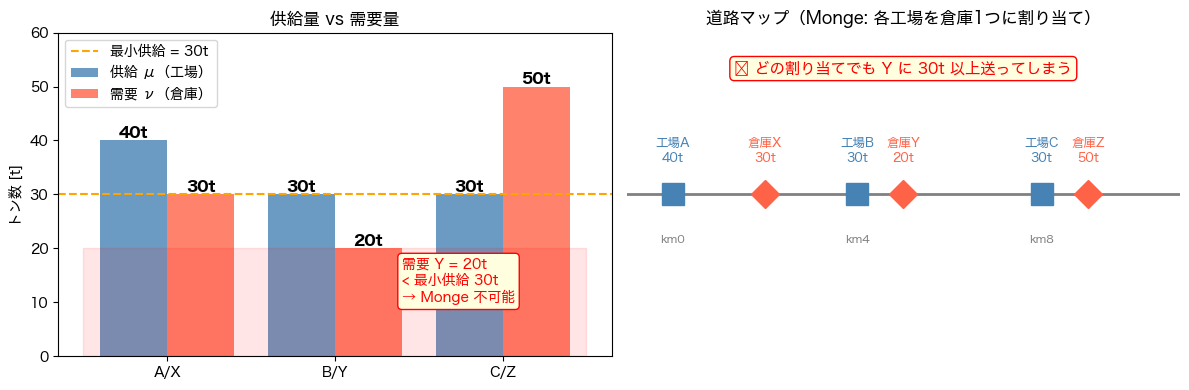

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 左: 供給 vs 需要の棒グラフ
x = np.arange(3)
s_vals = [supply[f] for f in F]
d_vals = [demand[w] for w in W]

bars1 = ax1.bar(x - 0.2, s_vals, 0.4, label='供給 μ（工場）', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + 0.2, d_vals, 0.4, label='需要 ν（倉庫）', color='tomato', alpha=0.8)

for bar, v in zip(bars1, s_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v}t', ha='center', fontsize=11, fontweight='bold')
for bar, v in zip(bars2, d_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v}t', ha='center', fontsize=11, fontweight='bold')

ax1.axhline(30, color='orange', linestyle='--', linewidth=1.5, label='最小供給 = 30t')
ax1.fill_between([-0.5, 2.5], 0, 20, alpha=0.1, color='red')
ax1.annotate('需要 Y = 20t\n< 最小供給 30t\n→ Monge 不可能', xy=(1.4, 10), fontsize=10,
             color='red', bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='red'))

ax1.set_xticks(x)
ax1.set_xticklabels(['A/X', 'B/Y', 'C/Z'])
ax1.set_ylabel('トン数 [t]')
ax1.set_title('供給量 vs 需要量')
ax1.legend()
ax1.set_ylim(0, 60)

# 右: 道路マップ
ax2.set_xlim(-1, 11)
ax2.set_ylim(-1, 3)
ax2.axhline(1, color='gray', linewidth=2, zorder=0)
ax2.set_title('道路マップ（Monge: 各工場を倉庫1つに割り当て）')
ax2.axis('off')

for f, km in km_f.items():
    ax2.plot(km, 1, 's', markersize=16, color='steelblue', zorder=3)
    ax2.text(km, 1.4, f'工場{f}\n{supply[f]}t', ha='center', fontsize=9, color='steelblue')
    ax2.text(km, 0.4, f'km{km}', ha='center', fontsize=8, color='gray')

for w, km in km_w.items():
    ax2.plot(km, 1, 'D', markersize=14, color='tomato', zorder=3)
    ax2.text(km, 1.4, f'倉庫{w}\n{demand[w]}t', ha='center', fontsize=9, color='tomato')

ax2.text(5, 2.5, '✗ どの割り当てでも Y に 30t 以上送ってしまう', ha='center',
         fontsize=11, color='red',
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='red'))

plt.tight_layout()
plt.savefig('monge.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 第2節：Kantorovich 問題

Monge の制約「丸ごと割り当て」を外し、**質量を分割できる輸送計画 π** を考える。

$$\min_{\pi \geq 0} \sum_{i,j} c_{ij}\, \pi_{ij}$$

$$\text{s.t.}\quad \sum_j \pi_{ij} = \mu_i\ (\forall i), \quad \sum_i \pi_{ij} = \nu_j\ (\forall j)$$

変数：$\pi_{AX}, \pi_{AY}, \pi_{AZ}, \pi_{BX}, \pi_{BY}, \pi_{BZ}, \pi_{CX}, \pi_{CY}, \pi_{CZ}$（9変数）  
制約：行和 = 供給、列和 = 需要（6本の等式）+ 非負制約

In [6]:
# 変数順序: [πAX, πAY, πAZ, πBX, πBY, πBZ, πCX, πCY, πCZ]
c_obj = C.flatten().tolist()   # [2,5,9, 2,1,5, 6,3,1]

# 等式制約: 行和（工場の供給） + 列和（倉庫の需要）
# 行 i の和: sum_j π[i,j] = supply[F[i]]
# 列 j の和: sum_i π[i,j] = demand[W[j]]
A_eq = np.zeros((6, 9))
for i in range(3):   # 行制約
    for j in range(3):
        A_eq[i, i*3 + j] = 1
for j in range(3):   # 列制約
    for i in range(3):
        A_eq[3+j, i*3 + j] = 1

b_eq = [supply[f] for f in F] + [demand[w] for w in W]

result_primal = linprog(c_obj, A_eq=A_eq, b_eq=b_eq,
                        bounds=[(0, None)]*9, method='highs')

pi_opt = result_primal.x.reshape(3, 3)
primal_val = result_primal.fun

print('=== Kantorovich 主問題の結果 ===')
print(f'最適コスト: {primal_val:.1f} ton·km')
print()
print('最適輸送計画 π* [t]:')
header = '         ' + ''.join(f'{w:>8}' for w in W) + '   行和(供給)'
print(header)
for i, f in enumerate(F):
    row = ''.join(f'{pi_opt[i,j]:>8.1f}' for j in range(3))
    print(f'  工場{f}:  {row}   = {pi_opt[i].sum():.0f}t')
print('  列和:  ' + ''.join(f'{pi_opt[:,j].sum():>8.1f}' for j in range(3)))
print('  (需要) ' + ''.join(f'{demand[w]:>8}' for w in W))

=== Kantorovich 主問題の結果 ===
最適コスト: 250.0 ton·km

最適輸送計画 π* [t]:
                X       Y       Z   行和(供給)
  工場A:      30.0     0.0    10.0   = 40t
  工場B:       0.0    20.0    10.0   = 30t
  工場C:       0.0     0.0    30.0   = 30t
  列和:      30.0    20.0    50.0
  (需要)       30      20      50


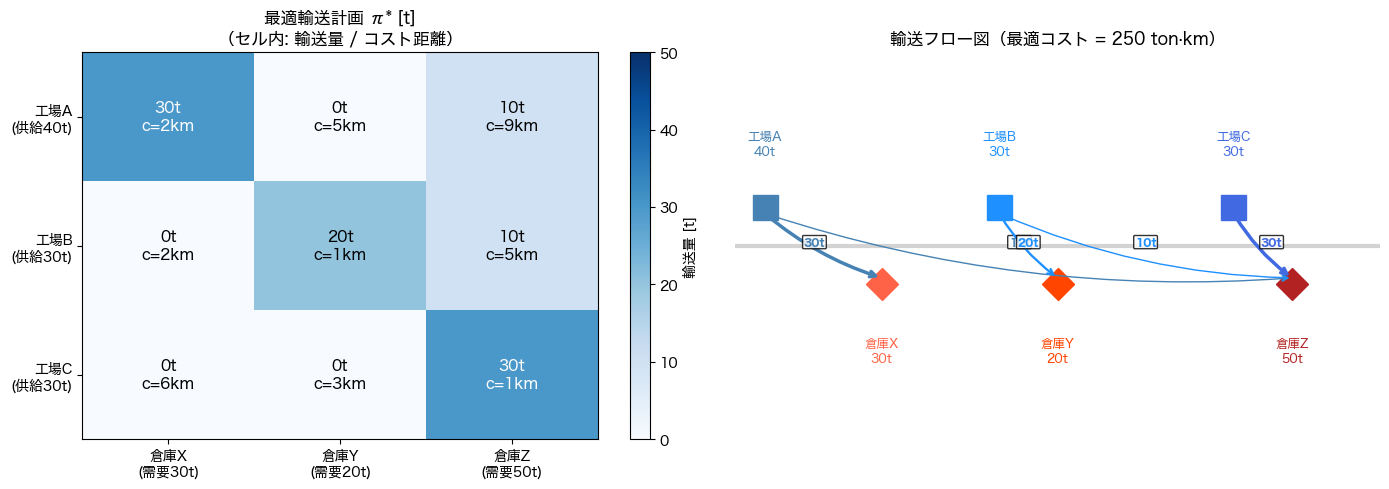

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: ヒートマップ
im = ax1.imshow(pi_opt, cmap='Blues', vmin=0, vmax=50, aspect='auto')
plt.colorbar(im, ax=ax1, label='輸送量 [t]')
for i in range(3):
    for j in range(3):
        v = pi_opt[i, j]
        color = 'white' if v > 25 else 'black'
        ax1.text(j, i, f'{v:.0f}t\nc={C[i,j]:.0f}km',
                 ha='center', va='center', fontsize=11, color=color)
ax1.set_xticks([0,1,2])
ax1.set_xticklabels([f'倉庫{w}\n(需要{demand[w]}t)' for w in W])
ax1.set_yticks([0,1,2])
ax1.set_yticklabels([f'工場{f}\n(供給{supply[f]}t)' for f in F])
ax1.set_title('最適輸送計画 π* [t]\n（セル内: 輸送量 / コスト距離）')

# 右: フロー図
ax2.set_xlim(-0.5, 10.5)
ax2.set_ylim(-0.5, 2.5)
ax2.axhline(1, color='lightgray', linewidth=3, zorder=0)
ax2.set_title(f'輸送フロー図（最適コスト = {primal_val:.0f} ton·km）')
ax2.axis('off')

colors_f = {'A': 'steelblue', 'B': 'dodgerblue', 'C': 'royalblue'}
colors_w = {'X': 'tomato', 'Y': 'orangered', 'Z': 'firebrick'}

for f, km in km_f.items():
    ax2.plot(km, 1.3, 's', markersize=18, color=colors_f[f], zorder=3)
    ax2.text(km, 1.7, f'工場{f}\n{supply[f]}t', ha='center', fontsize=9, color=colors_f[f])

for w, km in km_w.items():
    ax2.plot(km, 0.7, 'D', markersize=16, color=colors_w[w], zorder=3)
    ax2.text(km, 0.1, f'倉庫{w}\n{demand[w]}t', ha='center', fontsize=9, color=colors_w[w])

# 矢印でフロー描画（輸送量 > 0.5t のもの）
offsets = {'A': -0.15, 'B': 0, 'C': 0.15}
for i, f in enumerate(F):
    for j, w in enumerate(W):
        v = pi_opt[i, j]
        if v > 0.5:
            x1, x2 = km_f[f], km_w[w]
            ax2.annotate('', xy=(x2, 0.75), xytext=(x1, 1.25),
                         arrowprops=dict(arrowstyle='->', color=colors_f[f],
                                         lw=max(1, v/12), connectionstyle='arc3,rad=0.1'))
            mx, my = (x1+x2)/2 + offsets[f], 1.0
            ax2.text(mx, my, f'{v:.0f}t', fontsize=8, ha='center',
                     color=colors_f[f], fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('kantorovich.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 第3節：双対問題

**仲介業者**が工場・倉庫と契約し、輸送料金を設定するシナリオ。

- $\phi(i)$：工場 $i$ からの積み込み手数料（[円/t]）
- $\psi(j)$：倉庫 $j$ への荷降ろし手数料（[円/t]）
- 制約：合計手数料 ≤ 直送コスト（直接運んだほうが安い場合は仲介業者を使わない）

$$\max_{\phi, \psi} \sum_i \phi(i)\,\mu_i + \sum_j \psi(j)\,\nu_j \quad\text{s.t.}\quad \phi(i)+\psi(j) \leq c_{ij}\ \forall i,j$$

**Kantorovich 双対定理**（強双対性）：主問題の最適値 = 双対問題の最適値

In [8]:
# 変数順序: [φA, φB, φC, ψX, ψY, ψZ]
# 最大化 → -1 倍して最小化
c_dual = [-supply[f] for f in F] + [-demand[w] for w in W]
# c_dual = [-40, -30, -30, -30, -20, -50]

# 不等式制約: φ(i) + ψ(j) ≤ c(i,j) の 9 本
# 変数順序: [φA, φB, φC, ψX, ψY, ψZ]  (インデックス 0-5)
A_ub = []
b_ub = []
for i, f in enumerate(F):
    for j, w in enumerate(W):
        row = [0.0] * 6
        row[i] = 1.0      # φ(i)
        row[3 + j] = 1.0  # ψ(j)
        A_ub.append(row)
        b_ub.append(C[i, j])

result_dual = linprog(c_dual, A_ub=A_ub, b_ub=b_ub,
                      bounds=[(None, None)]*6, method='highs')

dual_vars = result_dual.x
phi = {f: dual_vars[i] for i, f in enumerate(F)}
psi = {w: dual_vars[3+j] for j, w in enumerate(W)}
dual_val = -result_dual.fun

print('=== 双対問題の結果 ===')
print(f'双対最適値: {dual_val:.1f} ton·km')
print()
print('積み込み手数料 φ（工場）:')
for f in F:
    print(f'  φ({f}) = {phi[f]:+.1f}')
print('荷降ろし手数料 ψ（倉庫）:')
for w in W:
    print(f'  ψ({w}) = {psi[w]:+.1f}')

=== 双対問題の結果 ===
双対最適値: 250.0 ton·km

積み込み手数料 φ（工場）:
  φ(A) = +0.0
  φ(B) = -4.0
  φ(C) = -8.0
荷降ろし手数料 ψ（倉庫）:
  ψ(X) = +2.0
  ψ(Y) = +5.0
  ψ(Z) = +9.0


In [9]:
# 制約検証テーブル
print('=== 双対制約の検証: φ(i) + ψ(j) ≤ c(i,j) ===')
print(f"  {'(工場,倉庫)':<12} {'φ(i)':>6} {'ψ(j)':>6} {'合計':>6} {'c(i,j)':>8} {'スラック':>8}  タイプ")
print('  ' + '-'*62)
for f in F:
    for w in W:
        lhs = phi[f] + psi[w]
        rhs = cost(f, w)
        slack = rhs - lhs
        kind = '等号 (tight)' if abs(slack) < 1e-6 else f'余裕 (+{slack:.1f})'
        print(f"  ({f},{w})          {phi[f]:>6.1f} {psi[w]:>6.1f} {lhs:>6.1f} {rhs:>8.1f} {slack:>8.1f}  {kind}")

=== 双対制約の検証: φ(i) + ψ(j) ≤ c(i,j) ===
  (工場,倉庫)        φ(i)   ψ(j)     合計   c(i,j)     スラック  タイプ
  --------------------------------------------------------------
  (A,X)             0.0    2.0    2.0      2.0      0.0  等号 (tight)
  (A,Y)             0.0    5.0    5.0      5.0      0.0  等号 (tight)
  (A,Z)             0.0    9.0    9.0      9.0      0.0  等号 (tight)
  (B,X)            -4.0    2.0   -2.0      2.0      4.0  余裕 (+4.0)
  (B,Y)            -4.0    5.0    1.0      1.0      0.0  等号 (tight)
  (B,Z)            -4.0    9.0    5.0      5.0      0.0  等号 (tight)
  (C,X)            -8.0    2.0   -6.0      6.0     12.0  余裕 (+12.0)
  (C,Y)            -8.0    5.0   -3.0      3.0      6.0  余裕 (+6.0)
  (C,Z)            -8.0    9.0    1.0      1.0      0.0  等号 (tight)


In [10]:
# 強双対性の確認
print('=== 強双対性の確認 ===')
print(f'Kantorovich 主問題の最適コスト: {primal_val:.4f} ton·km')
print(f'双対問題の最適値:               {dual_val:.4f} ton·km')
print(f'差: {abs(primal_val - dual_val):.2e}')
assert abs(primal_val - dual_val) < 1e-4, '強双対性が成立していない！'
print()
print(f'強双対性成立: 主問題 = 双対問題 = {primal_val:.1f} ton·km')

=== 強双対性の確認 ===
Kantorovich 主問題の最適コスト: 250.0000 ton·km
双対問題の最適値:               250.0000 ton·km
差: 0.00e+00

強双対性成立: 主問題 = 双対問題 = 250.0 ton·km


/var/folders/f6/_zsdfp150bs97yydnwbr85hc0000gn/T/ipykernel_73872/555211548.py:51: UserWarning: Glyph 8804 (\N{LESS-THAN OR EQUAL TO}) missing from font(s) Hiragino Sans.
  plt.tight_layout()
/var/folders/f6/_zsdfp150bs97yydnwbr85hc0000gn/T/ipykernel_73872/555211548.py:52: UserWarning: Glyph 8804 (\N{LESS-THAN OR EQUAL TO}) missing from font(s) Hiragino Sans.
  plt.savefig('dual.png', dpi=120, bbox_inches='tight')
/Users/a1t2s2u2/.pyenv/versions/3.10.14/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8804 (\N{LESS-THAN OR EQUAL TO}) missing from font(s) Hiragino Sans.
  fig.canvas.print_figure(bytes_io, **kw)


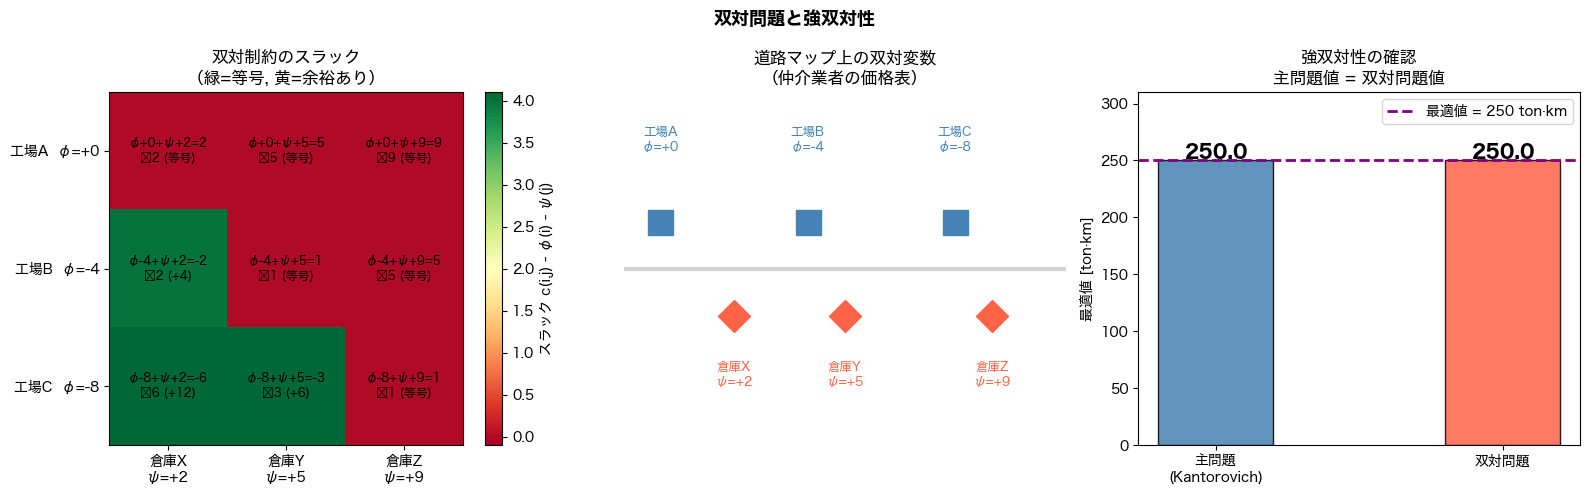

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 左: 双対制約のスラックヒートマップ
ax = axes[0]
slack_mat = np.array([[cost(f,w) - phi[f] - psi[w] for w in W] for f in F])
im = ax.imshow(slack_mat, cmap='RdYlGn', vmin=-0.1, vmax=4.1, aspect='auto')
plt.colorbar(im, ax=ax, label='スラック c(i,j) - φ(i) - ψ(j)')
for i, f in enumerate(F):
    for j, w in enumerate(W):
        s = slack_mat[i, j]
        kind = '等号' if abs(s) < 1e-6 else f'+{s:.0f}'
        ax.text(j, i, f'φ{phi[f]:+.0f}+ψ{psi[w]:+.0f}={phi[f]+psi[w]:.0f}\n≤{cost(f,w):.0f} ({kind})',
                ha='center', va='center', fontsize=8.5)
ax.set_xticks([0,1,2])
ax.set_xticklabels([f'倉庫{w}\nψ={psi[w]:+.0f}' for w in W])
ax.set_yticks([0,1,2])
ax.set_yticklabels([f'工場{f}  φ={phi[f]:+.0f}' for f in F])
ax.set_title('双対制約のスラック\n（緑=等号, 黄=余裕あり）')

# 中央: 道路マップ上に双対変数を表示
ax2 = axes[1]
ax2.set_xlim(-1, 11)
ax2.set_ylim(-0.5, 2.5)
ax2.axhline(1, color='lightgray', linewidth=3, zorder=0)
ax2.axis('off')
ax2.set_title('道路マップ上の双対変数\n（仲介業者の価格表）')
for f, km in km_f.items():
    ax2.plot(km, 1.4, 's', markersize=18, color='steelblue', zorder=3)
    ax2.text(km, 2.0, f'工場{f}\nφ={phi[f]:+.0f}', ha='center', fontsize=9, color='steelblue')
for w, km in km_w.items():
    ax2.plot(km, 0.6, 'D', markersize=16, color='tomato', zorder=3)
    ax2.text(km, 0.0, f'倉庫{w}\nψ={psi[w]:+.0f}', ha='center', fontsize=9, color='tomato')

# 右: 強双対性の比較
ax3 = axes[2]
vals = [primal_val, dual_val]
bars = ax3.bar(['主問題\n(Kantorovich)', '双対問題'],
               vals, color=['steelblue', 'tomato'], alpha=0.85,
               edgecolor='black', width=0.4)
for bar, v in zip(bars, vals):
    ax3.text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.1f}', ha='center',
             fontsize=14, fontweight='bold')
ax3.axhline(primal_val, color='purple', linestyle='--', linewidth=2,
            label=f'最適値 = {primal_val:.0f} ton·km')
ax3.set_ylim(0, 310)
ax3.set_ylabel('最適値 [ton·km]')
ax3.set_title('強双対性の確認\n主問題値 = 双対問題値')
ax3.legend()

plt.suptitle('双対問題と強双対性', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dual.png', dpi=120, bbox_inches='tight')
plt.show()

---
## まとめ

| 問題 | 結果 |
|------|------|
| **Monge 問題** | 解なし — ν(Y)=20t < 最小供給 30t、写像では質量を分割できない |
| **Kantorovich 問題** | A→X=30t, A→Z=10t, B→Y=20t, B→Z=10t, C→Z=30t、最適コスト = **250 ton·km** |
| **双対問題** | φ=(+2,-2,-6), ψ=(0,+3,+7)、双対値 = **250 ton·km** |
| **強双対性** | 主問題値 = 双対問題値 = 250 ✓ |

**Monge と Kantorovich の違い**：Monge は工場を「丸ごと」1 つの倉庫に割り当てる。  
Kantorovich は工場 A の 40t を「X に 30t + Z に 10t」と分割でき、常に最適解が存在する。

**双対問題の意味**：仲介業者が φ(工場)・ψ(倉庫) という価格表を設定し、  
「合計手数料 ≤ 直送コスト」という制約のもとで総収入を最大化すると、  
その最大値は Kantorovich の最小輸送コストに等しい（強双対性）。